# Titanic Mini Visualization Dashboard
## Data Science with Python

### Overview
A mini data visualization dashboard analyzing the Titanic dataset.
This notebook combines data cleaning, feature engineering, and 5 distinct
chart types to tell a complete data story.

**Dataset:** Titanic (891 passengers × 15 columns)
**Tools:** Python, Pandas, Seaborn, Matplotlib

## 1.  Setup
Importing libraries and applying consistent styling across all charts.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
print("Libraries ready!")

Libraries ready!


## 2️. Data Cleaning
Handling missing values and dropping irrelevant columns.

| Column | Action | Reason |
|--------|--------|--------|
| **age** | Fill with median | Robust to outliers |
| **embarked** | Fill with mode | Only 2 missing |
| **deck** | Drop | 77% missing |

In [2]:
df = sns.load_dataset('titanic')
print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3️. Feature Engineering
Creating 2 new features from existing columns to enable deeper analysis.
- **family_size** = SibSp + Parch (total family members onboard)
- **age_group** = Age bucketed into 5 meaningful categories

In [3]:
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df.drop(columns=['deck', 'embark_town', 'who', 'adult_male', 'alive', 'alone'], inplace=True)
print("Clean! Missing values:", df.isnull().sum().sum())

Clean! Missing values: 0


In [4]:
df['family_size'] = df['sibsp'] + df['parch']

bins   = [0, 12, 18, 30, 50, 80]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

print("Features created!")

Features created!


## 4️. Visualizations

### Chart 1: Age Distribution (Histogram)
How were passengers distributed across age groups?

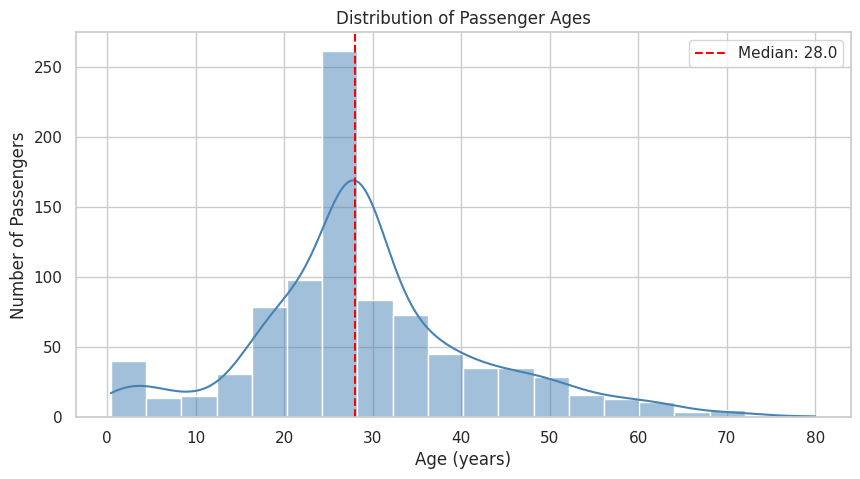

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df['age'], bins=20, kde=True, color='steelblue')
plt.axvline(df['age'].median(), color='red', linestyle='--', linewidth=1.5, label=f'Median: {df["age"].median():.1f}')
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age (years)')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

Most passengers were young adults (20–35).
The KDE curve shows a right skew — fewer older passengers onboard.
The red line marks the median age of 28.

### Chart 2: Survival Rate by Class & Gender (Bar Chart)
How did gender and class interact to affect survival?

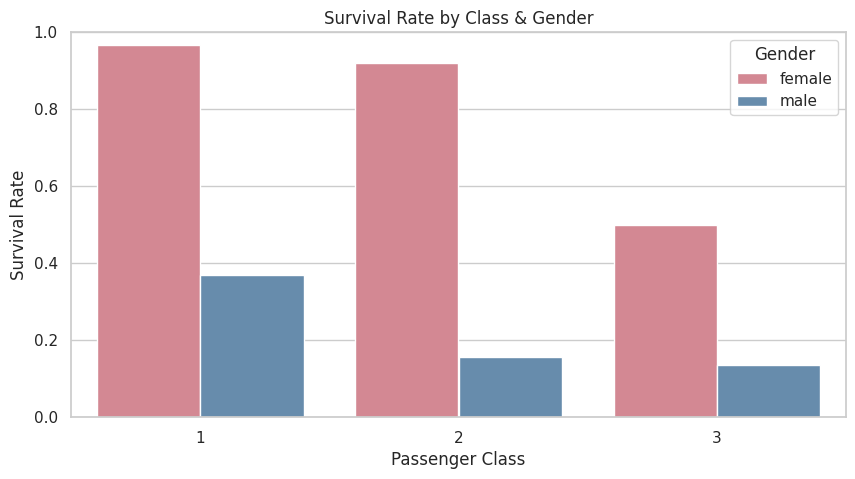

In [6]:
plt.figure(figsize=(10, 5))
sns.barplot(x='pclass', y='survived', hue='sex', data=df,
            palette=['#E07B8A', '#5B8DB8'], errorbar=None)
plt.title('Survival Rate by Class & Gender')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.legend(title='Gender')
plt.show()

1st class females had ~97% survival — the highest of any group.
Across all classes, females significantly outsurvived males.
Gender was a stronger predictor of survival than class alone.

### Chart 3: Fare Distribution by Class (Boxplot)
How much did passengers pay across different classes?

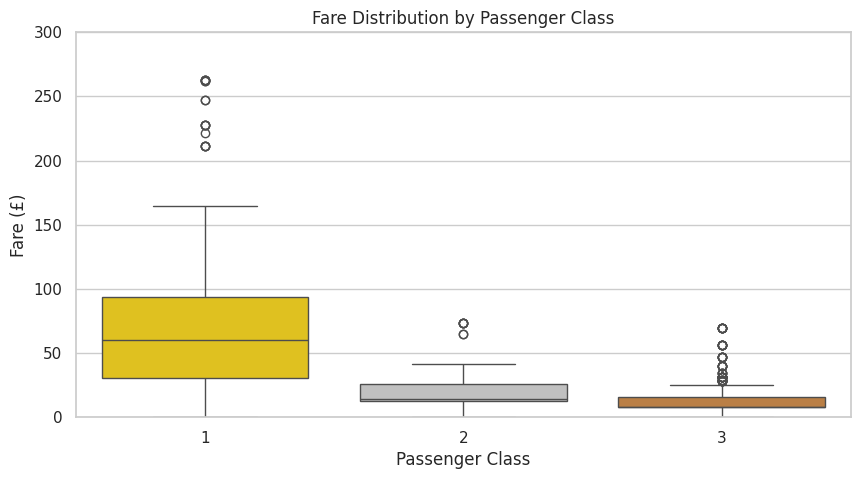

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='pclass', y='fare', data=df,
            hue='pclass', palette=['#FFD700', '#C0C0C0', '#CD7F32'],
            legend=False)
plt.title('Fare Distribution by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare (£)')
plt.ylim(0, 300)
plt.show()

1st class fares varied wildly (£10 to £170+) with several outliers above £200.
3rd class fares were consistently low and tightly clustered.
The dots above the boxes represent unusually expensive tickets.

### Chart 4: Age vs Fare (Scatterplot)
Is there a relationship between age, fare paid, and survival outcome?

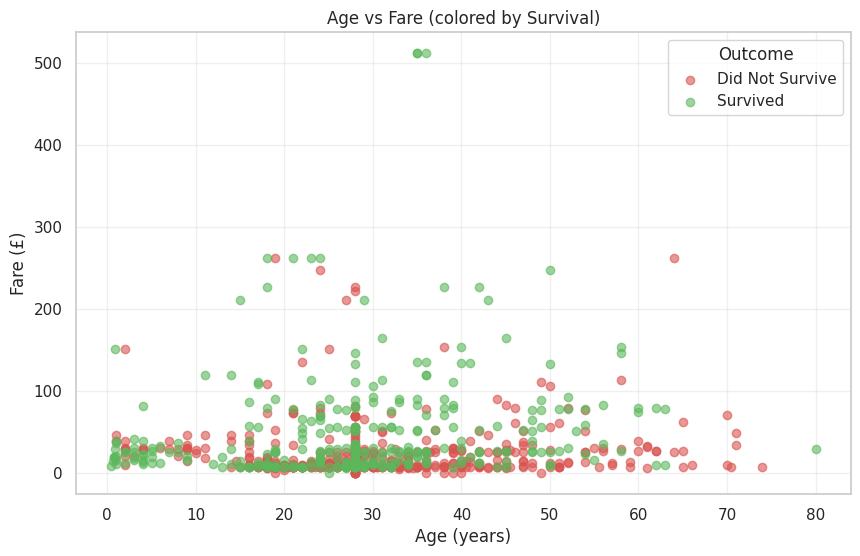

In [10]:
plt.figure(figsize=(10, 6))

# Plot non-survivors
not_survived = df[df['survived'] == 0]
survived = df[df['survived'] == 1]

plt.scatter(not_survived['age'], not_survived['fare'],
            color='#D9534F', alpha=0.6, label='Did Not Survive')
plt.scatter(survived['age'], survived['fare'],
            color='#5CB85C', alpha=0.6, label='Survived')

plt.title('Age vs Fare (colored by Survival)')
plt.xlabel('Age (years)')
plt.ylabel('Fare (£)')
plt.legend(title='Outcome')
plt.grid(True, alpha=0.3)
plt.show()

Higher fare passengers (top of chart) are mostly green — they survived.
Lower fare passengers cluster at the bottom with more red dots.
Age alone doesn't predict survival — fare (wealth) is the stronger signal.

### Chart 5: Correlation Heatmap
How strongly are all numeric variables related to each other?

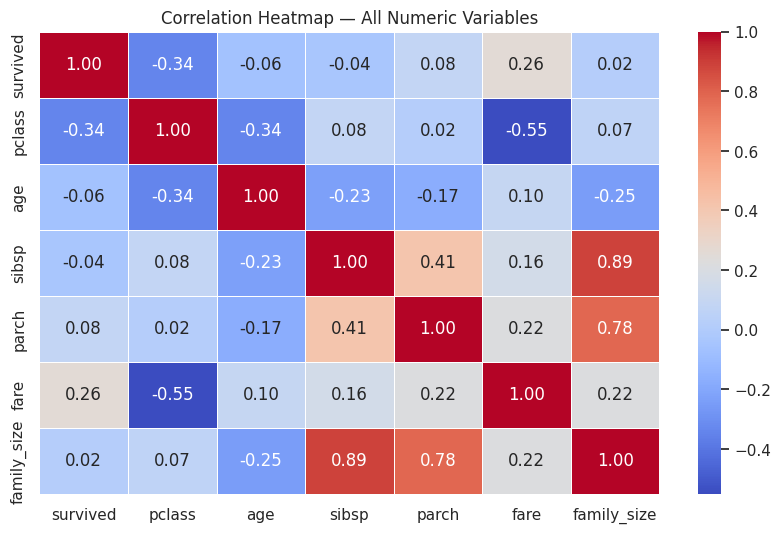

In [11]:
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — All Numeric Variables')
plt.show()

Strongest relationships found:
- fare vs pclass: -0.55 (higher class number = cheaper ticket)
- sibsp vs family_size: 0.89 (expected — family_size is built from sibsp)
- survived vs pclass: -0.34 (lower class = lower survival)
- survived vs fare: +0.26 (pricier ticket = slightly better survival)

## 5️. Conclusion

### Key Insights from this Dashboard:

| Chart | Key Finding |
|-------|------------|
| Histogram | Most passengers were aged 20–35 |
| Bar Chart | 1st class females had 97% survival rate |
| Boxplot | 1st class fares varied wildly; 3rd class was flat |
| Scatterplot | Higher fare = better survival chances |
| Heatmap | Fare & class are the strongest survival predictors |

### What this Dashboard taught me:
- Different chart types reveal different aspects of the same data
- Combining charts tells a far richer story than any single chart
- Feature engineering (family_size, age_group) unlocks hidden patterns
- A well-labeled chart communicates faster than a paragraph of text

*Data Science with Python Internship – Task 4*